# NLP search query theo tỉnh + cách người dùng gõ query

Ước tính **volume search** (`fact_user_events.query` trên pageview) theo tỉnh/thành:

| Phương án | Định nghĩa |
|-----------|------------|
| **Method A** | Chỉ tỉnh trích từ **text query** (rule-based lexicon) |
| **Method B** | Method A; nếu không có tỉnh trong query → fallback `city_name` của tin |

**Chạy nhanh (export CSV/PNG):**
`env/bin/python Thinh_Analyze/run_search_query_province_nlp.py --query-sample-frac 0.15 --choropleth`

**Output:** `Thinh_Analyze/outputs/search_query_province_nlp/`

### Đọc nhanh (sau khi chạy pipeline)

| Câu hỏi | Gợi ý đọc |
|---------|-----------|
| Có phải chỉ ~10 tỉnh được gõ tên? | **Không** — xem `SUMMARY.md` § Method A vs B |
| Bao nhiêu % query có tên tỉnh trong text? | ~10% (Method A); ~90% là `khong_ro_tinh` |
| Phân bổ thực tế theo tỉnh? | **Method B** + choropleth `maps/` |


In [11]:
%matplotlib inline
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

WORKDIR = Path.cwd().resolve()
if not (WORKDIR / "dim_listing").exists() and (WORKDIR.parent / "dim_listing").exists():
    DATA_ROOT = WORKDIR.parent
else:
    DATA_ROOT = WORKDIR
sys.path.insert(0, str(DATA_ROOT))

from Thinh_Analyze.search_query_province_nlp_lib import OUT_DIR, CAT_META, CATEGORIES
import Thinh_Analyze.run_search_query_province_nlp as pipeline

OUT = OUT_DIR
print("DATA_ROOT =", DATA_ROOT)
print("OUT =", OUT)


DATA_ROOT = /Users/dothinh_3112/Downloads/Datathon_Data
OUT = /Users/dothinh_3112/Downloads/Datathon_Data/Thinh_Analyze/outputs/search_query_province_nlp


## Chạy pipeline (hoặc đọc CSV đã export)


In [12]:
# Đặt RUN_PIPELINE=True để tái chạy (~1–2 ph với sample 15%)
RUN_PIPELINE = False
if RUN_PIPELINE:
    import sys
    _argv = sys.argv
    sys.argv = [
        "run_search_query_province_nlp.py",
        "--query-sample-frac", "0.15",
        "--choropleth",
    ]
    pipeline.main()
    sys.argv = _argv
else:
    display(Markdown("Đọc output có sẵn. Bật `RUN_PIPELINE=True` để tái tạo."))


Đọc output có sẵn. Bật `RUN_PIPELINE=True` để tái tạo.

## 1. Coverage


In [13]:
cov = pd.read_csv(OUT / "00_coverage_overall.csv")
dims = pd.read_csv(OUT / "00_coverage_by_dims.csv")
display(cov)
display(dims.head(12))


,query_sample_frac,n_events_sample,n_search_pv_sample,n_distinct_query,n_search_pv_est
0,0.15,24255573,662429,103560,4416193


,category,device,is_login,n_search_pv
0,1050,iOS,login,179644
1,1020,iOS,login,104731
2,1010,iOS,login,76738
3,1050,Android,login,54218
4,1020,Android,login,38712
5,1030,iOS,login,34934
6,1040,iOS,login,21018
7,1050,iOS,non-login,14748
8,1010,Android,login,13723
9,1030,Android,login,13658


## 2. Thống kê tỉnh — Method A vs B (markdown)

Bảng dưới trả lời: *có bao nhiêu tỉnh được match*, *% query không ghi tỉnh*, *taxonomy theo category*.


In [14]:
stats = pd.read_csv(OUT / "10_province_coverage_stats.csv")
display(stats)
summary_md = OUT / "SUMMARY.md"
if summary_md.exists():
    display(Markdown(summary_md.read_text(encoding="utf-8")))


,metric,value,unit
0,n_provinces_method_a,58.000000,NaN
1,n_provinces_method_b,59.000000,NaN
2,pct_volume_khong_ro_tinh_method_a,89.381707,%
3,pct_volume_khong_ro_tinh_method_b,0.001054,%
4,pct_volume_with_province_in_query,10.618293,%
5,top5_share_among_named_provinces_method_a,87.362404,%
6,top10_share_among_named_provinces_method_a,94.364245,%
7,top5_share_among_named_provinces_method_b,95.855196,%
8,pct_searches_has_explicit_province_flag,10.618136,%
9,cat_1010_pct_geo_explicit_province,6.929649,%


# Search query NLP theo tỉnh — thống kê tổng hợp

## Phạm vi dữ liệu

| Chỉ số | Giá trị |
|--------|---------|
| Sample `event_id` (hash) | 15% |
| Search pageview ước lượng (full) | 4,416,193 |
| Số query phân biệt (trong sample) | 103,560 |
| Nguồn | `fact_user_events`, `event_type=pageview`, có `query` |

## Method A vs B — có phải chỉ ~10 tỉnh được gõ tên?

**Không.** Lexicon match được nhiều tỉnh; nhưng **đa số query không chứa tên tỉnh** trong text.

| | Method A (chỉ text query) | Method B (text + `city_name` tin) |
|--|---------------------------|-----------------------------------|
| Số tỉnh có volume > 0 | **58** | **59** |
| Volume `khong_ro_tinh` | **89.4%** | **0.0%** |
| Volume có gán tỉnh | **10.6%** | **100.0%** |
| Top 5 tỉnh (trong phần đã gán tỉnh) | 87.4% volume | 95.9% volume |
| Top 10 tỉnh (Method A, phần có tỉnh) | 94.4% volume | — |

- **10.6%** search (weighted) có cờ `has_explicit_province` trong text.
- Phần còn lại Method A: query kiểu `quận 7`, `gò vấp`, `trọ` — không gõ TP/tỉnh.
- Method B gán tỉnh qua tin user click → gần đủ 63 tỉnh; HCM ~82% do cơ cấu nền tảng.

## Method A — top 15 tỉnh (có tên trong query)

| Tỉnh | Search ước lượng | % trong phần có tỉnh |
|------|------------------|----------------------|
| Tp Hồ Chí Minh | 289,200 | 62.4% |
| Đà Nẵng | 54,253 | 11.7% |
| Hà Nội | 25,341 | 5.5% |
| Bình Dương | 25,294 | 5.5% |
| Cần Thơ | 10,593 | 2.3% |
| Long An | 10,541 | 2.3% |
| Đồng Nai | 6,801 | 1.5% |
| Lâm Đồng | 5,826 | 1.3% |
| Bình Phước | 4,840 | 1.0% |
| Khánh Hòa | 4,426 | 1.0% |
| Tây Ninh | 3,414 | 0.7% |
| Điện Biên | 2,161 | 0.5% |
| Phú Thọ | 1,926 | 0.4% |
| Gia Lai | 1,807 | 0.4% |
| Vĩnh Long | 1,581 | 0.3% |

## Method B — top 15 tỉnh (NLP + fallback)

| Tỉnh | Search ước lượng | % trong phần có tỉnh |
|------|------------------|----------------------|
| Tp Hồ Chí Minh | 3,589,087 | 82.3% |
| Đà Nẵng | 257,713 | 5.9% |
| Bình Dương | 150,013 | 3.4% |
| Hà Nội | 143,680 | 3.3% |
| Cần Thơ | 41,119 | 0.9% |
| Đồng Nai | 38,647 | 0.9% |
| Long An | 34,879 | 0.8% |
| Bà Rịa - Vũng Tàu | 15,546 | 0.4% |
| Lâm Đồng | 12,847 | 0.3% |
| Bình Phước | 8,239 | 0.2% |
| Khánh Hòa | 8,000 | 0.2% |
| Tây Ninh | 7,806 | 0.2% |
| Quảng Nam | 7,500 | 0.2% |
| Đắk Lắk | 6,312 | 0.1% |
| Tiền Giang | 3,934 | 0.1% |

## Cách người dùng gõ query (taxonomy, % volume theo category)

| Category | Gõ **tên tỉnh** | Chỉ **quận/khu** | **Generic** (trọ, chung cư…) |
|----------|----------------|------------------|------------------------------|
| 1010 Căn hộ | 6.9% | 10.4% | 12.3% |
| 1020 Nhà ở | 9.3% | 17.2% | 7.6% |
| 1030 VP/MB | 3.4% | 19.1% | 17.1% |
| 1040 Đất | 17.4% | 5.0% | 6.8% |
| 1050 Phòng trọ | 13.6% | 16.7% | 29.9% |

## Refinement trong session

| Category | % search là đổi query (refinement) |
|----------|-----------------------------------|
| 1010 Căn hộ | 5.0% |
| 1020 Nhà ở | 4.0% |
| 1030 VP/MB | 3.8% |
| 1040 Đất | 3.1% |
| 1050 Phòng trọ | 4.9% |
| 6020  | 0.0% |

## Validation (query có tỉnh trong text vs `city_name` tin)

| Chỉ số | Giá trị |
|--------|---------|
| Weighted agreement | **94.7%** |
| Unweighted agreement | 84.7% |
| Số nhóm query (có cả NLP tỉnh + city) | 11,153 |

→ Khi user **gõ tên tỉnh**, thường khớp tỉnh tin đăng họ xem.

**Top lệch (NLP ≠ city tin):**

- NLP `Bình Phước` vs tin `Tp Hồ Chí Minh`: 502 lượt
- NLP `Phú Thọ` vs tin `Tp Hồ Chí Minh`: 264 lượt
- NLP `Bình Dương` vs tin `Tp Hồ Chí Minh`: 260 lượt
- NLP `Tp Hồ Chí Minh` vs tin `Bình Dương`: 244 lượt
- NLP `Điện Biên` vs tin `Tp Hồ Chí Minh`: 216 lượt

## Đọc nhanh cho slide

1. **Không phải chỉ 10 tỉnh** — Method A thấy ~58 tỉnh trong text; Method B ~59 tỉnh.
2. **~90% query không ghi tỉnh** (Method A) — hay gõ quận/từ khóa.
3. **HCM + Đà Nẵng + HN** chiếm phần lớn phần có tên tỉnh trong query.
4. Muốn **phân bổ search theo tỉnh thực tế** → ưu tiên **Method B** hoặc UI geo filter (không có trong `query`).

_File số liệu: `10_province_coverage_stats.csv`_

## 2b. Volume theo tỉnh — bảng & chart


In [15]:
vol_a = pd.read_csv(OUT / "01_volume_by_province_method_a.csv")
vol_b = pd.read_csv(OUT / "02_volume_by_province_method_b.csv")
delta = pd.read_csv(OUT / "03_delta_a_vs_b.csv")
for title, df in [
    ("Method A (NLP text)", vol_a.groupby("province")["n_searches_est"].sum().nlargest(12)),
    ("Method B (NLP + fallback)", vol_b.groupby("province")["n_searches_est"].sum().nlargest(12)),
]:
    display(Markdown(f"**{title}**"))
    display(df.reset_index())
display(Markdown("**Delta B − A (national)**"))
display(delta.head(12))


**Method A (NLP text)**

,province,n_searches_est
0,khong_ro_tinh,3899260
1,Tp Hồ Chí Minh,289200
2,Đà Nẵng,54253
3,Hà Nội,25341
4,Bình Dương,25294
5,Cần Thơ,10593
6,Long An,10541
7,Đồng Nai,6801
8,Lâm Đồng,5826
9,Bình Phước,4840


**Method B (NLP + fallback)**

,province,n_searches_est
0,Tp Hồ Chí Minh,3589087
1,Đà Nẵng,257713
2,Bình Dương,150013
3,Hà Nội,143680
4,Cần Thơ,41119
5,Đồng Nai,38647
6,Long An,34879
7,Bà Rịa - Vũng Tàu,15546
8,Lâm Đồng,12847
9,Bình Phước,8239


**Delta B − A (national)**

,province,n_method_a,n_method_b,delta,pct_lift
0,Tp Hồ Chí Minh,289200.0,3589087,3299887.0,1141.039765
1,Đà Nẵng,54253.0,257713,203460.0,375.020736
2,Bình Dương,25294.0,150013,124719.0,493.077410
3,Hà Nội,25341.0,143680,118339.0,466.986307
4,Đồng Nai,6801.0,38647,31846.0,468.254668
5,Cần Thơ,10593.0,41119,30526.0,288.171434
6,Long An,10541.0,34879,24338.0,230.888910
7,Bà Rịa - Vũng Tàu,888.0,15546,14658.0,1650.675676
8,Lâm Đồng,5826.0,12847,7021.0,120.511500
9,Quảng Nam,1226.0,7500,6274.0,511.745514


### fig_top_provinces_method_a.png

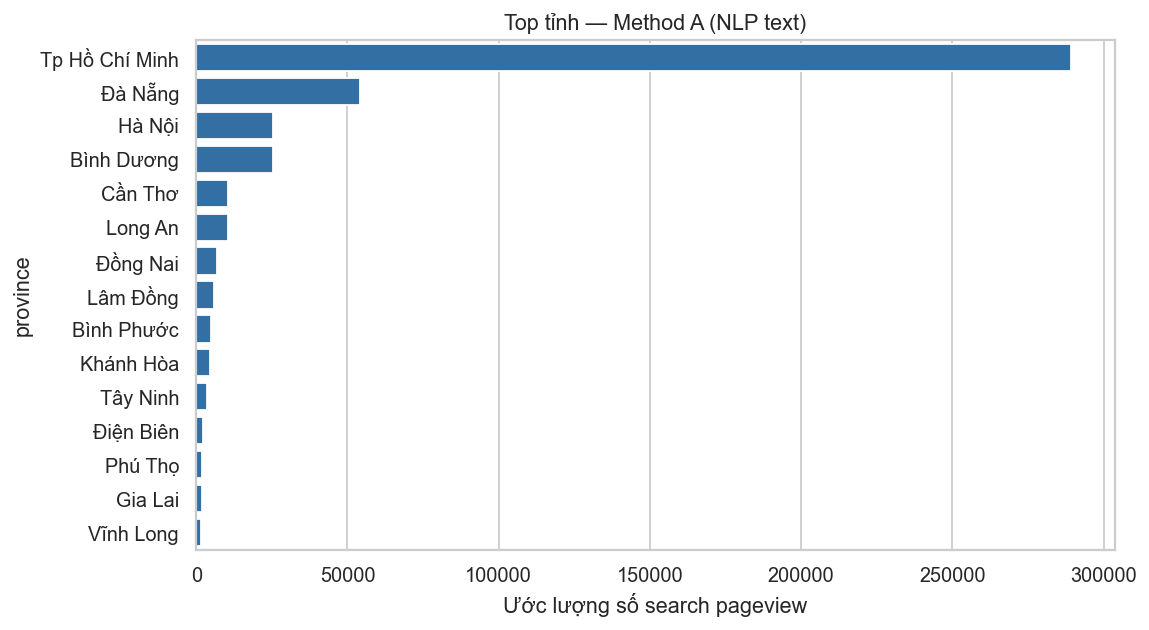

### fig_top_provinces_method_b.png

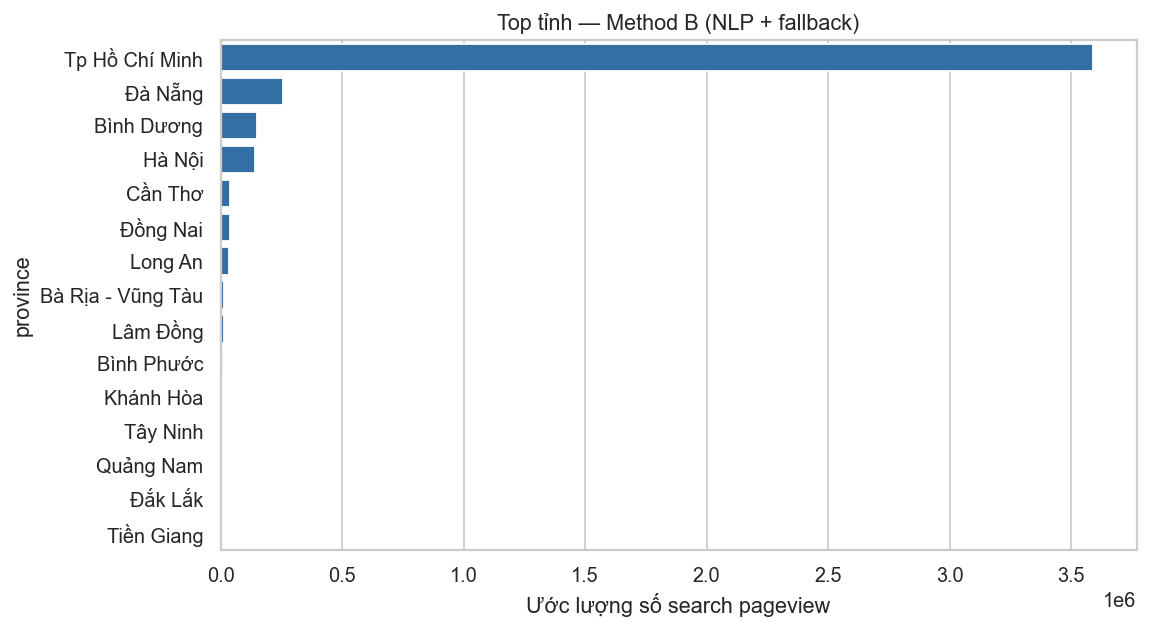

### fig_region_stack_method_b.png

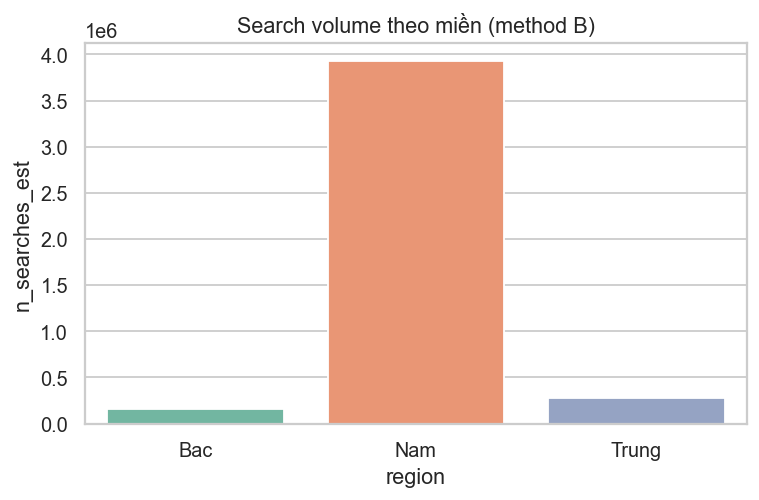

In [16]:
for name in [
    "fig_top_provinces_method_a.png",
    "fig_top_provinces_method_b.png",
    "fig_region_stack_method_b.png",
]:
    p = OUT / name
    if p.exists():
        display(Markdown(f"### {name}"))
        display(Image(filename=str(p)))


## 3. Validation NLP vs `city_name` tin


,n_rows,n_weighted,pct_agreement_unweighted,pct_agreement_weighted
0,11153,69482,84.694701,94.650413


,province_nlp,city_name_canon,n
0,Bình Phước,Tp Hồ Chí Minh,502
1,Phú Thọ,Tp Hồ Chí Minh,264
2,Bình Dương,Tp Hồ Chí Minh,260
3,Tp Hồ Chí Minh,Bình Dương,244
4,Điện Biên,Tp Hồ Chí Minh,216
5,Gia Lai,Tp Hồ Chí Minh,169
6,Hậu Giang,Tp Hồ Chí Minh,137
7,Hòa Bình,Tp Hồ Chí Minh,126
8,Long An,Tp Hồ Chí Minh,117
9,Điện Biên,Đà Nẵng,101


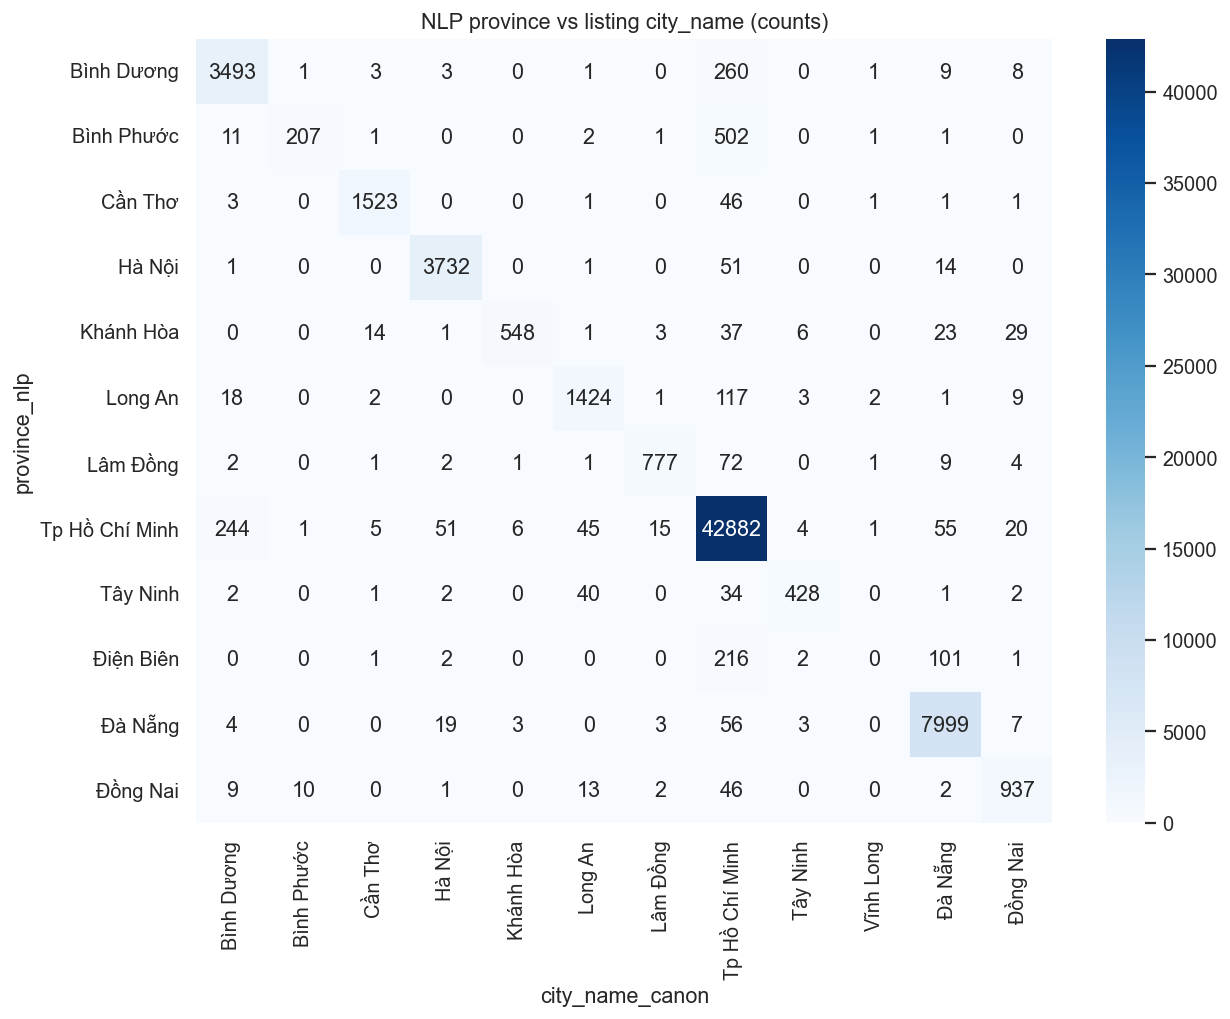

In [17]:
val = pd.read_csv(OUT / "08_validation_summary.csv")
mis = pd.read_csv(OUT / "08_validation_mislabels.csv")
display(val)
display(mis.head(15))
p = OUT / "fig_validation_heatmap.png"
if p.exists():
    display(Image(filename=str(p)))


## 4. Cách người dùng query (taxonomy & n-grams)


,category,taxonomy,n,share_pct
12,1010,other,62489,57.286262
0,1010,full_phrase,14197,13.014980
1,1010,generic,13102,12.011148
2,1010,geo_district_only,8870,8.131497
8,1010,geo_explicit_province|full_phrase,4839,4.436112
7,1010,geo_explicit_province,2679,2.455951
3,1010,geo_district_only|full_phrase,2102,1.926991
13,1010,price_led,276,0.253021
28,1020,other,98533,54.994447
18,1020,geo_district_only,21529,12.016030


,ngram_type,ngram,n
0,bigram,phong tro,136643
1,bigram,cho thue,118489
2,bigram,thue phong,50935
3,bigram,thue nha,44015
4,bigram,ho chi,40627
5,bigram,chi minh,40594
6,bigram,nguyen can,39841
7,bigram,tp ho,39555
8,bigram,tro o,36236
9,bigram,nha nguyen,35098


,category,n_search_events,n_refinements,pct_refinement
0,1010,110642,5539,5.01
1,1020,182229,7377,4.05
2,1030,58972,2216,3.76
3,1040,37446,1153,3.08
4,1050,273139,13355,4.89
5,6020,1,0,0.00


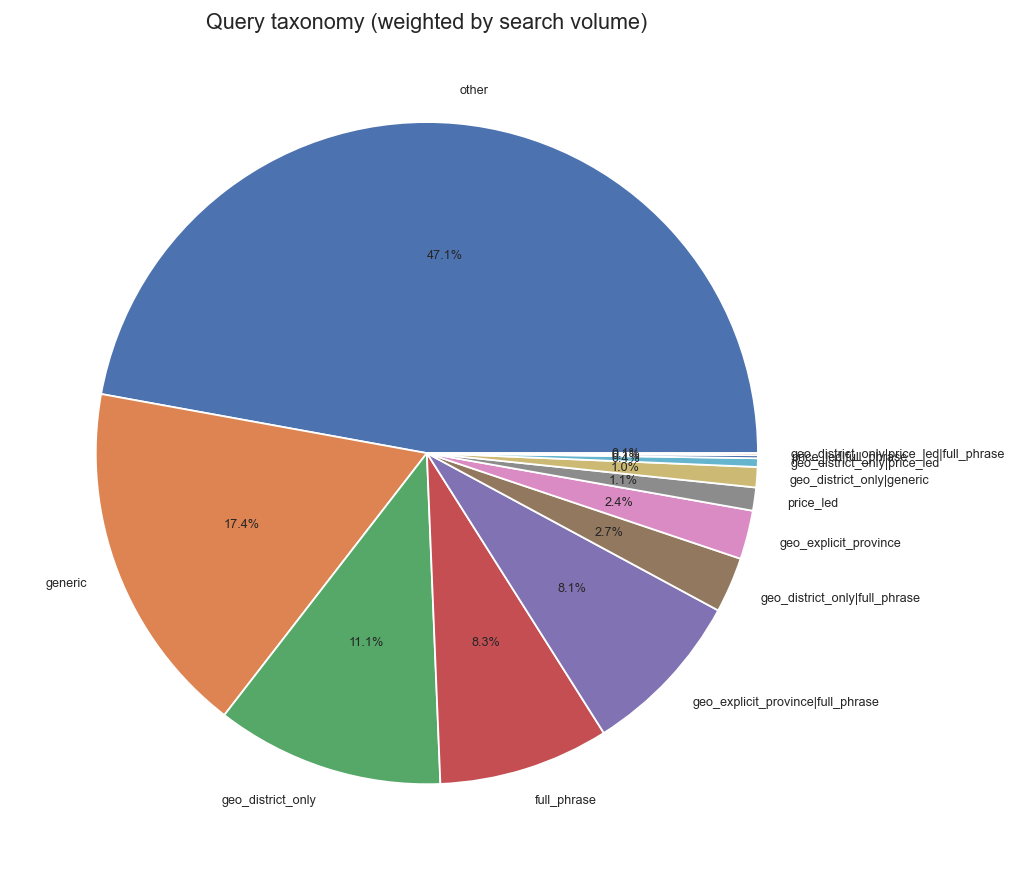

In [18]:
tax = pd.read_csv(OUT / "04_query_taxonomy_counts.csv")
ngrams = pd.read_csv(OUT / "06_bigrams_trigrams.csv")
refine = pd.read_csv(OUT / "07_refinement_proxy.csv")
display(tax.sort_values(["category", "n"], ascending=[True, False]).groupby("category").head(8))
display(ngrams.head(20))
display(refine)
p = OUT / "fig_taxonomy_donut.png"
if p.exists():
    display(Image(filename=str(p)))


## 5. Top query theo tỉnh (method B) — ví dụ category 1050


In [19]:
cat = 1050
path = OUT / f"05_top_queries_by_province_{cat}.csv"
if path.exists():
  top = pd.read_csv(path)
  display(Markdown(f"**{CAT_META[cat]} ({cat})**"))
  for prov, g in top.groupby("province"):
      display(Markdown(f"#### {prov}"))
      display(g.nlargest(8, "n")[["query", "n"]])
      break  # first province demo
  display(top.head(25))


**Phòng trọ (1050)**

#### An Giang

,query,n
0,nhà trọ,3
1,nhà ở long xuyên,3
2,Nhà trọ,1
3,nhà trọ bình khánh,1
4,phòng trọ gần đại học ag,1
5,phòng trọ tịnh biên an giang,1


,geo_method_b,query,n,province
0,An Giang,nhà trọ,3,An Giang
1,An Giang,nhà ở long xuyên,3,An Giang
2,An Giang,Nhà trọ,1,An Giang
3,An Giang,nhà trọ bình khánh,1,An Giang
4,An Giang,phòng trọ gần đại học ag,1,An Giang
5,An Giang,phòng trọ tịnh biên an giang,1,An Giang
6,Bà Rịa - Vũng Tàu,phòng trọ,59,Bà Rịa - Vũng Tàu
7,Bà Rịa - Vũng Tàu,phòng trọ vũng tàu,35,Bà Rịa - Vũng Tàu
8,Bà Rịa - Vũng Tàu,cho thuê phòng trọ,12,Bà Rịa - Vũng Tàu
9,Bà Rịa - Vũng Tàu,nhà trọ,9,Bà Rịa - Vũng Tàu


## 6. Choropleth search volume (method B)


### fig_search_volume_choropleth_1010.png

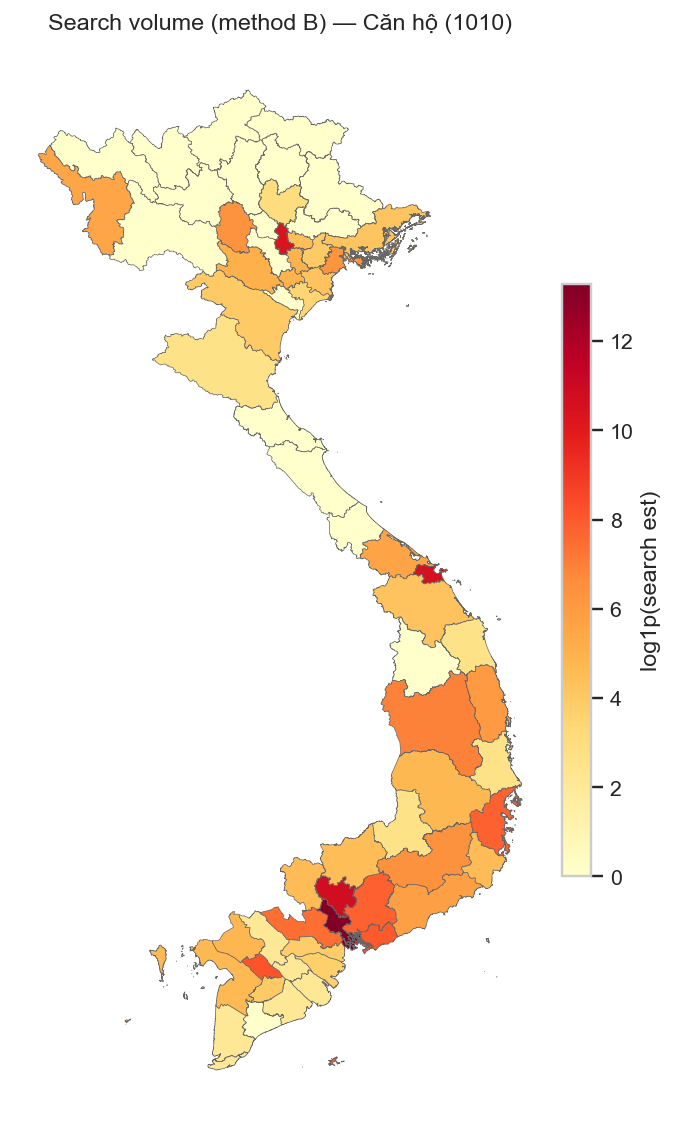

### fig_search_volume_choropleth_1020.png

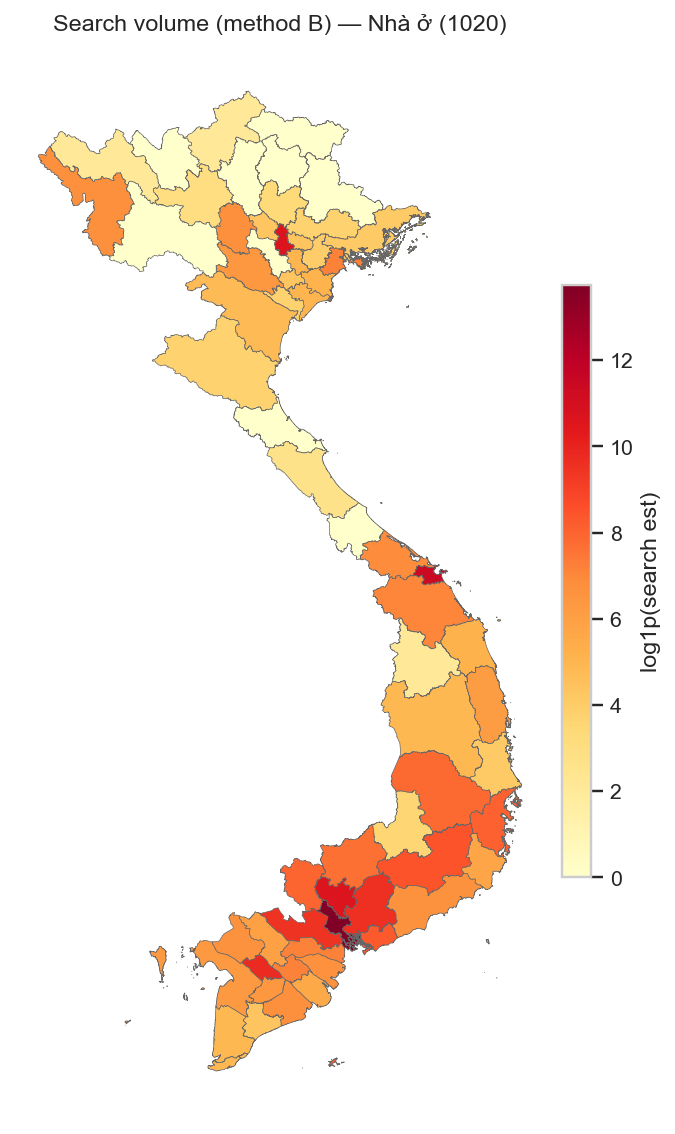

### fig_search_volume_choropleth_1030.png

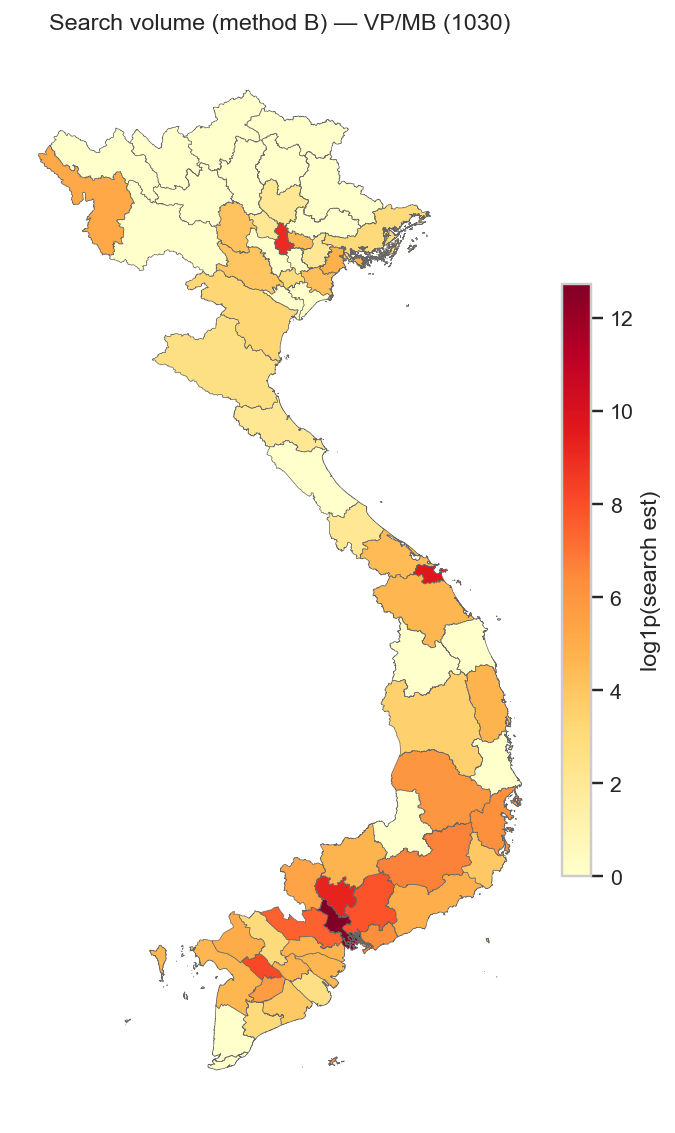

_… và 2 map khác trong `/Users/dothinh_3112/Downloads/Datathon_Data/Thinh_Analyze/outputs/search_query_province_nlp/maps`_

In [20]:
from IPython.display import Image
maps = sorted((OUT / "maps").glob("fig_search_volume_choropleth_*.png"))
for p in maps[:3]:
    display(Markdown(f"### {p.name}"))
    display(Image(filename=str(p)))
if len(maps) > 3:
    display(Markdown(f"_… và {len(maps)-3} map khác trong `{OUT / 'maps'}`_"))


## 7. Search vs explicit events (exploratory)


In [21]:
gap_path = OUT / "09_search_vs_explicit_gap.csv"
if gap_path.exists():
    gap = pd.read_csv(gap_path)
    display(Markdown("**Search volume vs explicit events (exploratory)**"))
    display(gap.nlargest(10, "n_searches_est")[["province", "n_searches_est", "n_explicit_events"]])


**Search volume vs explicit events (exploratory)**

,province,n_searches_est,n_explicit_events
48,Tp Hồ Chí Minh,3589087.0,365063.0
56,Đà Nẵng,257713.0,24205.0
2,Bình Dương,150013.0,18731.0
15,Hà Nội,143680.0,28508.0
11,Cần Thơ,41119.0,4117.0
59,Đồng Nai,38647.0,7909.0
26,Long An,34879.0,6631.0
1,Bà Rịa - Vũng Tàu,15546.0,4029.0
28,Lâm Đồng,12847.0,2245.0
3,Bình Phước,8239.0,1313.0
